## Setup and Imports

In [13]:
import sys
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

project_root = Path().resolve().parents[1]
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from utils.helpers import set_style, save_figure, start_logging
set_style()
log = start_logging(project_root, '04_04_churn_risk_scoring')

print('All imports successful')

Logging started — 2026-04-28 11:47:25.605968
Log: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Gamezone/gamezone-analytics/logs/04_04_churn_risk_scoring.txt
All imports successful


## Load Data

In [14]:
processed_path = project_root / 'data' / 'processed'

# Survival dataset with all customer features
survival_df = pd.read_csv(processed_path / 'survival_data.csv')

# Cox model predictions from Notebook 3
cox_pred = pd.read_csv(processed_path / 'cox_predictions.csv')

# RFM segments from Project 02
rfm = pd.read_csv(processed_path / 'rfm_segments.csv')

# Churn config
config = pd.read_csv(processed_path / 'churn_config.csv').iloc[0]
CHURN_THRESHOLD = int(config['churn_threshold_days'])

print(f'Survival dataset: {len(survival_df):,} customers')
print(f'Cox predictions:  {len(cox_pred):,} customers')
print(f'Churn threshold:  {CHURN_THRESHOLD} days')

log(f'Data loaded: {len(survival_df):,} customers')

Survival dataset: 13,778 customers
Cox predictions:  13,778 customers
Churn threshold:  180 days
Data loaded: 13,778 customers


## Build Churn Risk Score


In [15]:
# Merge survival data with Cox predictions
df = survival_df.merge(
    cox_pred[['USER_ID', 'predicted_hazard', 'predicted_median_survival']],
    on='USER_ID', how='left'
)

# Normalise each component to 0-100
def normalise_to_100(series):
    s_min = series.min()
    s_max = series.max()
    if s_max == s_min:
        return pd.Series(50, index=series.index)
    return ((series - s_min) / (s_max - s_min) * 100)

# Component 1: hazard score (higher hazard = higher risk)
df['hazard_score'] = normalise_to_100(
    df['predicted_hazard'].fillna(df['predicted_hazard'].median())
)

# Component 2: recency score (higher recency = higher risk)
df['recency_score'] = normalise_to_100(df['recency_days'])

# Component 3: inverse RFM score (lower RFM = higher risk)
df['inv_rfm_score'] = 100 - normalise_to_100(df['RFM_score'])

# Weighted composite score
# Hazard (40%) + Recency (40%) + Inverse RFM (20%)
# Hazard and recency are equally weighted as both are strong signals
# RFM is secondary as it was built on the same data
df['churn_risk_score'] = (
    0.40 * df['hazard_score'] +
    0.40 * df['recency_score'] +
    0.20 * df['inv_rfm_score']
).round(1)

print(f'Churn risk scores computed for {df["churn_risk_score"].notna().sum():,} customers')
print()
print('Risk score distribution:')
print(df['churn_risk_score'].describe().round(1))

Churn risk scores computed for 13,778 customers

Risk score distribution:
count    13778.0
mean        39.8
std         19.1
min          5.2
25%         24.5
50%         35.5
75%         54.2
max         92.0
Name: churn_risk_score, dtype: float64


In [16]:
# Assign risk tiers
# Based on score distribution quartiles
df['risk_tier'] = pd.cut(
    df['churn_risk_score'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low', 'Medium', 'High', 'Critical'],
    include_lowest=True
)

tier_summary = df.groupby('risk_tier', observed=True).agg(
    customers     = ('USER_ID',          'count'),
    avg_score     = ('churn_risk_score',  'mean'),
    avg_spend     = ('total_spend',       'mean'),
    churn_rate    = ('churned',           'mean')
).round(2)

tier_summary['revenue_at_risk'] = (
    tier_summary['customers'] * tier_summary['avg_spend']
).round(0)

print('Risk tier summary:')
print(tier_summary.to_string())

log('Risk tiers assigned')
log(tier_summary.to_string())

Risk tier summary:
           customers  avg_score  avg_spend  churn_rate  revenue_at_risk
risk_tier                                                              
Low             3623      18.77     456.23        0.15        1652921.0
Medium          5973      35.46     299.12        0.88        1786644.0
High            3429      60.64     214.67        1.00         736103.0
Critical         753      81.19      94.24        1.00          70963.0
Risk tiers assigned
           customers  avg_score  avg_spend  churn_rate  revenue_at_risk
risk_tier                                                              
Low             3623      18.77     456.23        0.15        1652921.0
Medium          5973      35.46     299.12        0.88        1786644.0
High            3429      60.64     214.67        1.00         736103.0
Critical         753      81.19      94.24        1.00          70963.0


## Retention Priority Matrix

In [17]:
# Build retention priority matrix
# High CLV = above median total spend
# High Risk = above median churn risk score

spend_median = df['total_spend'].median()
risk_median  = df['churn_risk_score'].median()

df['clv_tier']  = np.where(df['total_spend'] >= spend_median, 'High CLV', 'Low CLV')
df['risk_band'] = np.where(df['churn_risk_score'] >= risk_median, 'High Risk', 'Low Risk')
df['priority_quadrant'] = df['clv_tier'] + ' / ' + df['risk_band']

priority_summary = df.groupby('priority_quadrant').agg(
    customers      = ('USER_ID',          'count'),
    avg_spend      = ('total_spend',       'mean'),
    avg_risk_score = ('churn_risk_score',  'mean'),
    total_revenue  = ('total_spend',       'sum')
).round(2)

print('Retention priority matrix:')
print(priority_summary.to_string())
print()

# Define action for each quadrant
actions = {
    'High CLV / High Risk':  'PRIORITY 1 - Immediate retention action. High value customers slipping away.',
    'High CLV / Low Risk':   'PRIORITY 2 - Monitor and nurture. Valuable and stable but do not ignore.',
    'Low CLV / High Risk':   'PRIORITY 3 - Low-cost re-engagement only. Not worth heavy investment.',
    'Low CLV / Low Risk':    'PRIORITY 4 - Minimal action. Stable but not high value.'
}

for quadrant, action in actions.items():
    if quadrant in priority_summary.index:
        n = priority_summary.loc[quadrant, 'customers']
        rev = priority_summary.loc[quadrant, 'total_revenue']
        print(f'{quadrant}')
        print(f'  Customers: {n:,}  |  Revenue at stake: ${rev:,.0f}')
        print(f'  Action: {action}')
        print()

Retention priority matrix:
                      customers  avg_spend  avg_risk_score  total_revenue
priority_quadrant                                                        
High CLV / High Risk       3210     420.78           52.75     1350703.28
High CLV / Low Risk        4814     504.87           23.00     2430434.92
Low CLV / High Risk        3698      73.93           57.91      273394.19
Low CLV / Low Risk         2056      93.44           26.61      192104.29

High CLV / High Risk
  Customers: 3,210  |  Revenue at stake: $1,350,703
  Action: PRIORITY 1 - Immediate retention action. High value customers slipping away.

High CLV / Low Risk
  Customers: 4,814  |  Revenue at stake: $2,430,435
  Action: PRIORITY 2 - Monitor and nurture. Valuable and stable but do not ignore.

Low CLV / High Risk
  Customers: 3,698  |  Revenue at stake: $273,394
  Action: PRIORITY 3 - Low-cost re-engagement only. Not worth heavy investment.

Low CLV / Low Risk
  Customers: 2,056  |  Revenue at stake: 

## Visualisations

Figure saved → reports/figures/04_04_risk_score_distribution.png


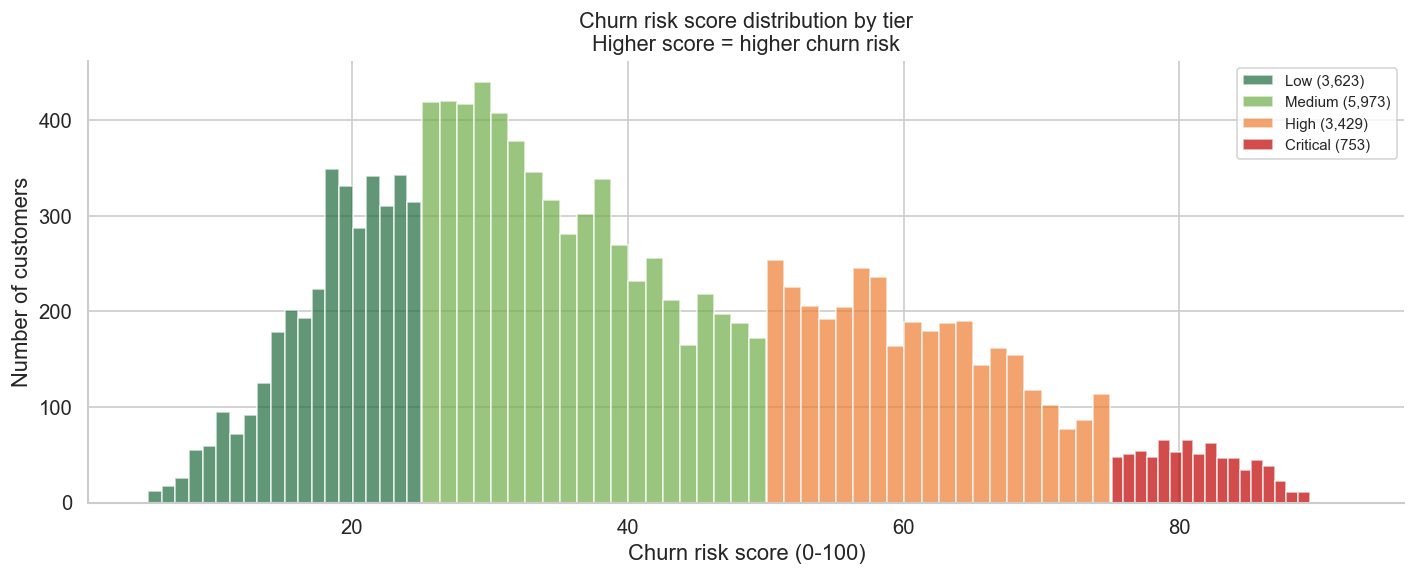

In [18]:
# Chart 1: Churn risk score distribution
fig, ax = plt.subplots(figsize=(12, 5))

tier_colors = {'Low': '#1E6B3C', 'Medium': '#70AD47',
               'High': '#ED7D31', 'Critical': '#C00000'}

for tier in ['Low', 'Medium', 'High', 'Critical']:
    subset = df[df['risk_tier'] == tier]['churn_risk_score']
    ax.hist(subset, bins=20, alpha=0.7, color=tier_colors[tier],
            label=f'{tier} ({len(subset):,})', edgecolor='white')

ax.set_title('Churn risk score distribution by tier\n'
             'Higher score = higher churn risk',
             fontsize=13, fontweight='medium')
ax.set_xlabel('Churn risk score (0-100)')
ax.set_ylabel('Number of customers')
ax.legend(fontsize=9)

save_figure(fig, '04_04_risk_score_distribution.png')
plt.show()

Figure saved → reports/figures/04_04_risk_score_by_segment.png


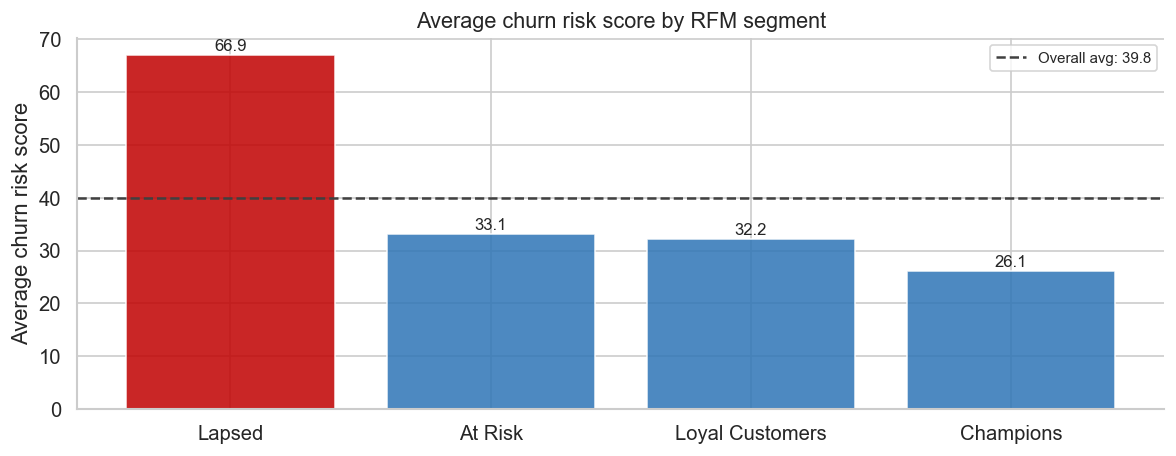

In [19]:
# Chart 2: Risk score by RFM segment
seg_risk = df.groupby('segment')['churn_risk_score'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#C00000' if v > df['churn_risk_score'].mean() else '#2E75B6'
          for v in seg_risk.values]
bars = ax.bar(seg_risk.index, seg_risk.values, color=colors, alpha=0.85) # pyright: ignore[reportArgumentType]
ax.axhline(df['churn_risk_score'].mean(), color='#404040',
           linestyle='--', linewidth=1.5,
           label=f'Overall avg: {df["churn_risk_score"].mean():.1f}')

for bar, val in zip(bars, seg_risk.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Average churn risk score by RFM segment',
             fontsize=13, fontweight='medium')
ax.set_ylabel('Average churn risk score')
ax.legend(fontsize=9)

save_figure(fig, '04_04_risk_score_by_segment.png')
plt.show()

Figure saved → reports/figures/04_04_retention_priority_matrix.png


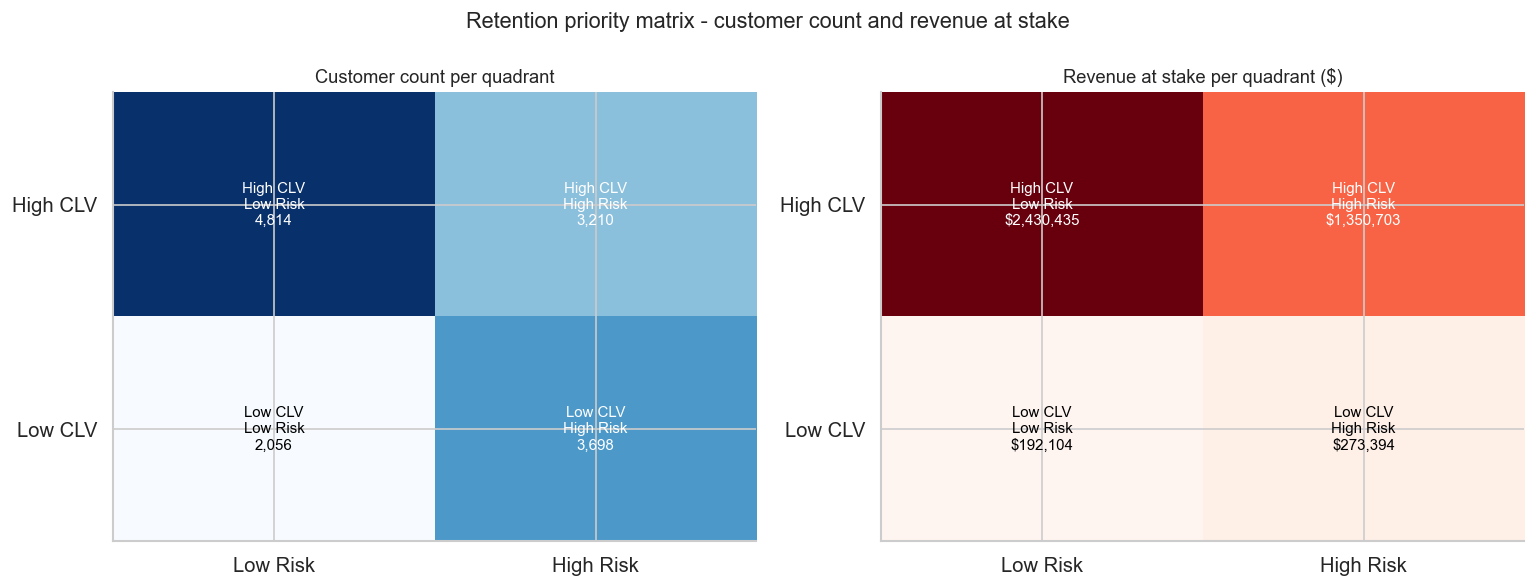

In [20]:
# Chart 3: Retention priority matrix heatmap
# 2x2 grid showing customer count and revenue at stake per quadrant

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

quadrants = [
    ('High CLV / Low Risk',  'High CLV / High Risk'),
    ('Low CLV / Low Risk',   'Low CLV / High Risk')
]

quad_data_n   = np.zeros((2, 2))
quad_data_rev = np.zeros((2, 2))
quad_labels   = [['High CLV\nLow Risk', 'High CLV\nHigh Risk'],
                  ['Low CLV\nLow Risk',  'Low CLV\nHigh Risk']]

for i, clv in enumerate(['High CLV', 'Low CLV']):
    for j, risk in enumerate(['Low Risk', 'High Risk']):
        key = f'{clv} / {risk}'
        if key in priority_summary.index:
            quad_data_n[i, j]   = priority_summary.loc[key, 'customers']
            quad_data_rev[i, j] = priority_summary.loc[key, 'total_revenue']

im1 = axes[0].imshow(quad_data_n, cmap='Blues', aspect='auto')
axes[0].set_title('Customer count per quadrant', fontsize=11, fontweight='medium')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{quad_labels[i][j]}\n{quad_data_n[i,j]:,.0f}',
                    ha='center', va='center', fontsize=9,
                    color='white' if quad_data_n[i,j] > quad_data_n.max()/2 else 'black')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Low Risk', 'High Risk'])
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['High CLV', 'Low CLV'])

im2 = axes[1].imshow(quad_data_rev, cmap='Reds', aspect='auto')
axes[1].set_title('Revenue at stake per quadrant ($)', fontsize=11, fontweight='medium')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{quad_labels[i][j]}\n${quad_data_rev[i,j]:,.0f}',
                    ha='center', va='center', fontsize=9,
                    color='white' if quad_data_rev[i,j] > quad_data_rev.max()/2 else 'black')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Low Risk', 'High Risk'])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['High CLV', 'Low CLV'])

fig.suptitle('Retention priority matrix - customer count and revenue at stake',
             fontsize=13, fontweight='medium')
save_figure(fig, '04_04_retention_priority_matrix.png')
plt.show()

Figure saved → reports/figures/04_04_risk_vs_clv_scatter.png


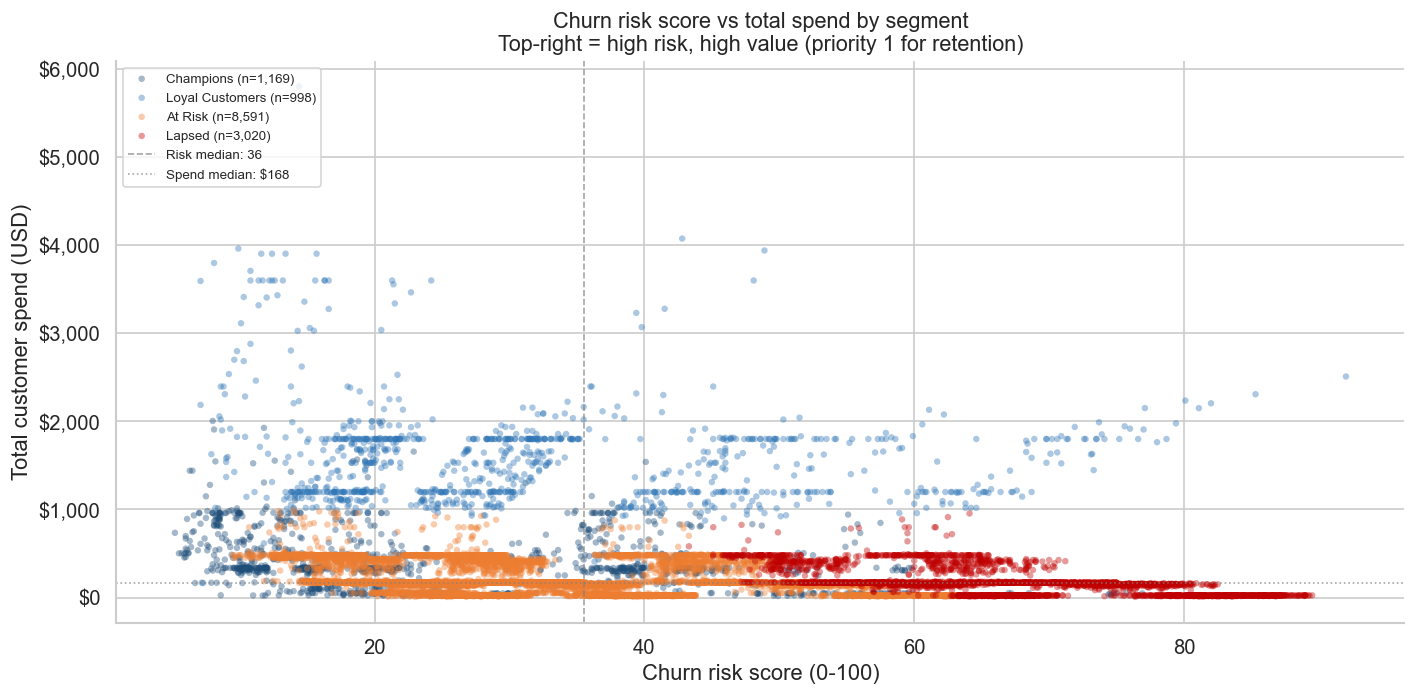

In [21]:
# Chart 4: Risk score vs CLV scatter
fig, ax = plt.subplots(figsize=(12, 6))

seg_colors_map = {
    'Champions':      '#1F4E79',
    'Loyal Customers':'#2E75B6',
    'At Risk':        '#ED7D31',
    'Lapsed':         '#C00000'
}

for seg in ['Champions', 'Loyal Customers', 'At Risk', 'Lapsed']:
    subset = df[df['segment'] == seg]
    ax.scatter(
        subset['churn_risk_score'],
        subset['total_spend'],
        c=seg_colors_map.get(seg, 'grey'),
        label=f'{seg} (n={len(subset):,})',
        alpha=0.4, s=15, edgecolors='none'
    )

ax.axvline(risk_median, color='grey', linestyle='--',
           linewidth=1, alpha=0.7, label=f'Risk median: {risk_median:.0f}')
ax.axhline(spend_median, color='grey', linestyle=':',
           linewidth=1, alpha=0.7, label=f'Spend median: ${spend_median:.0f}')

ax.set_title('Churn risk score vs total spend by segment\n'
             'Top-right = high risk, high value (priority 1 for retention)',
             fontsize=13, fontweight='medium')
ax.set_xlabel('Churn risk score (0-100)')
ax.set_ylabel('Total customer spend (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=8, loc='upper left')

save_figure(fig, '04_04_risk_vs_clv_scatter.png')
plt.show()

## Findings

In [22]:
critical_customers = (df['risk_tier'] == 'Critical').sum()
high_clv_high_risk = len(df[(df['clv_tier'] == 'High CLV') &
                             (df['risk_band'] == 'High Risk')])
p1_revenue = priority_summary.loc['High CLV / High Risk', 'total_revenue'] \
    if 'High CLV / High Risk' in priority_summary.index else 0

lowest_risk_seg  = seg_risk.idxmin()
highest_risk_seg = seg_risk.idxmax()


print('Notebook 4 Findings - Churn Risk Scoring')
print()
print('Risk Score Summary')
print(f'  Customers scored : {df["churn_risk_score"].notna().sum():,}')
print(f'  Mean risk score  : {df["churn_risk_score"].mean():.1f}')
print(f'  Median risk score: {df["churn_risk_score"].median():.1f}')
print(f'  Critical tier    : {critical_customers:,} customers (score 75-100)')
print()

print('Finding 1 - High CLV / High Risk customers are the primary retention priority')
print(f'  {high_clv_high_risk:,} customers are simultaneously high value and high risk.')
print(f'  Combined revenue at stake: ${p1_revenue:,.0f}')
print(f'  These customers have a demonstrated spend history but are showing')
print(f'  signs of disengagement. A targeted retention campaign on this group')
print(f'  delivers the highest expected return of any retention action.')
print()
print('Finding 2 - RFM segmentation is a valid proxy for churn risk')
print(f'  Lowest risk segment : {lowest_risk_seg} (avg score {seg_risk[lowest_risk_seg]:.1f})')
print(f'  Highest risk segment: {highest_risk_seg} (avg score {seg_risk[highest_risk_seg]:.1f})')
print(f'  The {seg_risk[highest_risk_seg] - seg_risk[lowest_risk_seg]:.1f}-point gap between {highest_risk_seg} and {lowest_risk_seg} confirms that')
print(f'  RFM-derived segments align with independently computed risk scores.')
print(f'  This internal consistency validates both the segmentation (Project 02)')
print(f'  and the scoring model built in this notebook.')
print()
print('Finding 3 - Lapsed customers do not justify personalised retention spend')
lapsed_rev = priority_summary.loc['Low CLV / High Risk', 'total_revenue'] \
    if 'Low CLV / High Risk' in priority_summary.index else 0
lapsed_n = priority_summary.loc['Low CLV / High Risk', 'customers'] \
    if 'Low CLV / High Risk' in priority_summary.index else 0
print(f'  {lapsed_n:,} Low CLV / High Risk customers account for only ${lapsed_rev:,.0f} in revenue.')
print(f'  The expected return from retaining a Lapsed customer does not cover')
print(f'  the cost of a personalised campaign. A single automated re-engagement')
print(f'  email is the appropriate and proportionate action for this group.')
print()
print('Finding 4 - Dataset constraints limit the precision of the hazard component')
print(f'  The risk score is a weighted composite: hazard (40%), recency (40%),')
print(f'  inverse RFM (20%). The Cox model achieved a concordance of 0.89, but')
print(f'  because 72.5% of customers churned within the first day, the model had')
print(f'  limited survival variation to learn from. The hazard component is less')
print(f'  discriminating than it would be on a dataset with richer temporal spread.')
print(f'  Recency and inverse RFM carry the more reliable signal in this build.')
print()
print('Retention Recommendations by Priority')
print('  Priority 1 - High CLV / High Risk : immediate personalised outreach')
print('  Priority 2 - High CLV / Low Risk  : loyalty nurture, quarterly touchpoint')
print('  Priority 3 - Low CLV / High Risk  : single automated re-engagement email')
print('  Priority 4 - Low CLV / Low Risk   : no active retention investment')

Notebook 4 Findings - Churn Risk Scoring

Risk Score Summary
  Customers scored : 13,778
  Mean risk score  : 39.8
  Median risk score: 35.5
  Critical tier    : 753 customers (score 75-100)

Finding 1 - High CLV / High Risk customers are the primary retention priority
  3,210 customers are simultaneously high value and high risk.
  Combined revenue at stake: $1,350,703
  These customers have a demonstrated spend history but are showing
  signs of disengagement. A targeted retention campaign on this group
  delivers the highest expected return of any retention action.

Finding 2 - RFM segmentation is a valid proxy for churn risk
  Lowest risk segment : Champions (avg score 26.1)
  Highest risk segment: Lapsed (avg score 66.9)
  The 40.8-point gap between Lapsed and Champions confirms that
  RFM-derived segments align with independently computed risk scores.
  This internal consistency validates both the segmentation (Project 02)
  and the scoring model built in this notebook.

Finding 

In [23]:
critical_customers = (df['risk_tier'] == 'Critical').sum()
high_clv_high_risk = len(df[(df['clv_tier'] == 'High CLV') &
                             (df['risk_band'] == 'High Risk')])
p1_revenue = priority_summary.loc['High CLV / High Risk', 'total_revenue'] \
    if 'High CLV / High Risk' in priority_summary.index else 0

lowest_risk_seg  = seg_risk.idxmin()
highest_risk_seg = seg_risk.idxmax()

# --- Print & log findings ---

print('Notebook 4 Findings - Churn Risk Scoring')
log('Notebook 4 Findings - Churn Risk Scoring')
print()

print('Risk Score Summary')
log('Risk Score Summary')
print(f'  Customers scored : {df["churn_risk_score"].notna().sum():,}')
print(f'  Mean risk score  : {df["churn_risk_score"].mean():.1f}')
print(f'  Median risk score: {df["churn_risk_score"].median():.1f}')
print(f'  Critical tier    : {critical_customers:,} customers (score 75-100)')
log(f'  Customers scored : {df["churn_risk_score"].notna().sum():,}')
log(f'  Mean risk score  : {df["churn_risk_score"].mean():.1f}')
log(f'  Median risk score: {df["churn_risk_score"].median():.1f}')
log(f'  Critical tier    : {critical_customers:,} customers (score 75-100)')
print()

print('Finding 1 - High CLV / High Risk customers are the primary retention priority')
log('Finding 1 - High CLV / High Risk customers are the primary retention priority')
print(f'  {high_clv_high_risk:,} customers are simultaneously high value and high risk.')
print(f'  Combined revenue at stake: ${p1_revenue:,.0f}')
print(f'  These customers have a demonstrated spend history but are showing')
print(f'  signs of disengagement. A targeted retention campaign on this group')
print(f'  delivers the highest expected return of any retention action.')
log(f'  {high_clv_high_risk:,} customers | Revenue at stake: ${p1_revenue:,.0f}')
print()

print('Finding 2 - RFM segmentation is a valid proxy for churn risk')
log('Finding 2 - RFM segmentation is a valid proxy for churn risk')
print(f'  Lowest risk segment : {lowest_risk_seg} (avg score {seg_risk[lowest_risk_seg]:.1f})')
print(f'  Highest risk segment: {highest_risk_seg} (avg score {seg_risk[highest_risk_seg]:.1f})')
print(f'  The {seg_risk[highest_risk_seg] - seg_risk[lowest_risk_seg]:.1f}-point gap between {highest_risk_seg} and {lowest_risk_seg} confirms that')
print(f'  RFM-derived segments align with independently computed risk scores.')
print(f'  This internal consistency validates both the segmentation (Project 02)')
print(f'  and the scoring model built in this notebook.')
log(f'  {lowest_risk_seg}: {seg_risk[lowest_risk_seg]:.1f} | {highest_risk_seg}: {seg_risk[highest_risk_seg]:.1f}')
print()

print('Finding 3 - Lapsed customers do not justify personalised retention spend')
log('Finding 3 - Lapsed customers do not justify personalised retention spend')
lapsed_rev = priority_summary.loc['Low CLV / High Risk', 'total_revenue'] \
    if 'Low CLV / High Risk' in priority_summary.index else 0
lapsed_n = priority_summary.loc['Low CLV / High Risk', 'customers'] \
    if 'Low CLV / High Risk' in priority_summary.index else 0
print(f'  {lapsed_n:,} Low CLV / High Risk customers account for only ${lapsed_rev:,.0f} in revenue.')
print(f'  The expected return from retaining a Lapsed customer does not cover')
print(f'  the cost of a personalised campaign. A single automated re-engagement')
print(f'  email is the appropriate and proportionate action for this group.')
log(f'  Low CLV / High Risk: {lapsed_n:,} customers | ${lapsed_rev:,.0f} revenue')
print()

print('Finding 4 - Dataset constraints limit the precision of the hazard component')
log('Finding 4 - Dataset constraints limit the precision of the hazard component')
print(f'  The risk score is a weighted composite: hazard (40%), recency (40%),')
print(f'  inverse RFM (20%). The Cox model achieved a concordance of 0.89, but')
print(f'  because 72.5% of customers churned within the first day, the model had')
print(f'  limited survival variation to learn from. The hazard component is less')
print(f'  discriminating than it would be on a dataset with richer temporal spread.')
print(f'  Recency and inverse RFM carry the more reliable signal in this build.')
log('  Hazard component precision limited by 72.5% day-1 churn rate in source data')
print()

print('Retention Recommendations by Priority')
log('Retention Recommendations by Priority')
print('  Priority 1 - High CLV / High Risk : immediate personalised outreach')
print('  Priority 2 - High CLV / Low Risk  : loyalty nurture, quarterly touchpoint')
print('  Priority 3 - Low CLV / High Risk  : single automated re-engagement email')
print('  Priority 4 - Low CLV / Low Risk   : no active retention investment')
log('  P1: personalised outreach | P2: nurture | P3: re-engagement email | P4: none')

Notebook 4 Findings - Churn Risk Scoring
Notebook 4 Findings - Churn Risk Scoring

Risk Score Summary
Risk Score Summary
  Customers scored : 13,778
  Mean risk score  : 39.8
  Median risk score: 35.5
  Critical tier    : 753 customers (score 75-100)
  Customers scored : 13,778
  Mean risk score  : 39.8
  Median risk score: 35.5
  Critical tier    : 753 customers (score 75-100)

Finding 1 - High CLV / High Risk customers are the primary retention priority
Finding 1 - High CLV / High Risk customers are the primary retention priority
  3,210 customers are simultaneously high value and high risk.
  Combined revenue at stake: $1,350,703
  These customers have a demonstrated spend history but are showing
  signs of disengagement. A targeted retention campaign on this group
  delivers the highest expected return of any retention action.
  3,210 customers | Revenue at stake: $1,350,703

Finding 2 - RFM segmentation is a valid proxy for churn risk
Finding 2 - RFM segmentation is a valid proxy 

## Export

In [24]:
# Export full risk-scored customer table
risk_output = df[[
    'USER_ID', 'segment', 'primary_channel', 'primary_region',
    'total_spend', 'total_orders', 'recency_days', 'churned', 'duration',
    'churn_risk_score', 'risk_tier', 'clv_tier', 'risk_band',
    'priority_quadrant', 'RFM_score'
]].copy()

output_path = processed_path / 'churn_risk_scores.csv'
risk_output.to_csv(output_path, index=False)

# Export priority summary
priority_summary.to_csv(processed_path / 'retention_priority_summary.csv')

print(f'Exported: churn_risk_scores.csv ({len(risk_output):,} customers)')
print(f'Exported: retention_priority_summary.csv ({len(priority_summary)} quadrants)')

Exported: churn_risk_scores.csv (13,778 customers)
Exported: retention_priority_summary.csv (4 quadrants)
